# Evaluating Trained FM Models' Performance

In [1]:
import os
import sys

from corner import corner

sys.path.append('..')

from src.simulator import Model, BurstSimulator
from src.flow_matching.distributions import Prior, Posterior
from src.flow_matching.probability_path import GuidedLinearProbabilityPath
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPGuidedVectorField, FRBLightCurveCNN, LightCurveThinner, fourier_embedding
from src.helpers import record_every, plot_posterior_samples

import numpy as np
import torch
import yaml

from src.flow_matching.plotting import plot_loss, plot_snapshots
from src.flow_matching.helpers import choose_device, build_mlp, find_run_dir

device = choose_device()

In [2]:
MODELS = {
    "MLPGuidedVectorField": MLPGuidedVectorField
}

TIME_ENCODERS = {
    "LightCurveThinner": LightCurveThinner,
    "FRBLightCurveCNN": FRBLightCurveCNN
}

TAU_ENCODERS = {
    True : fourier_embedding,
    False : None 
}

THETA_ENCODERS = {
    True : lambda theta_dim : build_mlp([2] + [2 * 4, 2 * 8] + [theta_dim]),
    False : None
}

In [3]:
# fill in desired job_id or directory name 
job_id = "12616712" #False
run_dir = None
save_dir = "../checkpoints/"

In [4]:
# loading the model (via run_id, or path)
run_dir = find_run_dir(job_id, save_dir) if job_id else os.path.join(save_dir, run_dir)

checkpoint_path = os.path.join(run_dir, 'training_checkpoint.pth')
config_path     = os.path.join(run_dir, 'config.yaml')

In [5]:
# create empty model from config
def empty_model_from_config(path):
    with open(path, 'r') as f:
        config = yaml.safe_load(f)
    
    model_name = config["model"]["name"]
    model_class = MODELS[model_name]
    
    kwargs = config["model"]["init_params"]

    time_encoder = config["time_seq_encoder"]["name"]
    t_encoder_kwargs = config["time_seq_encoder"]["init_params"]


    kwargs['time_seq_encoder']  = TIME_ENCODERS[time_encoder](**t_encoder_kwargs)
    kwargs['tau_encoder']   = TAU_ENCODERS[config["tau_encoder"]]
    kwargs['theta_encoder'] = THETA_ENCODERS[config["theta_encoder"]]
    
    return model_class(**kwargs)

vector_field = empty_model_from_config(config_path)

In [6]:
# load trained model 
checkpoint = torch.load(checkpoint_path, weights_only=False)
vector_field.load_state_dict(checkpoint["model_state_dict"])
vector_field.eval()
vector_field.to(device)

losses = checkpoint["losses"]

# Loss

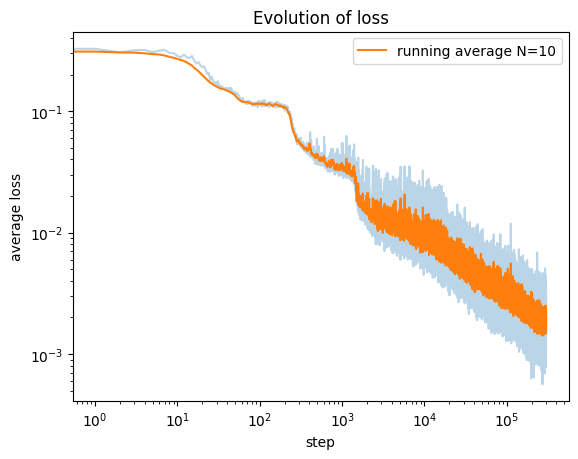

In [7]:
plot_loss(losses, window_size=10)

# Example posterior

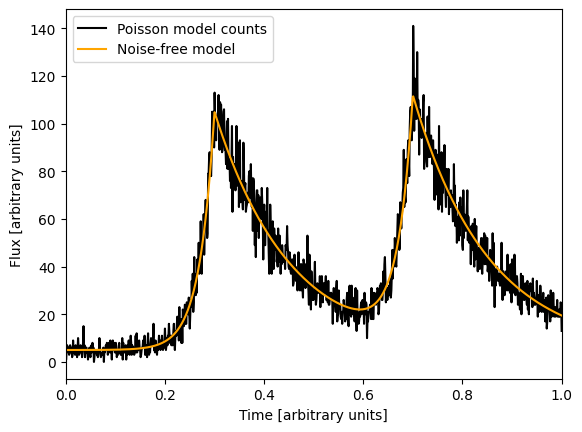

In [7]:
N = 2
time = np.linspace(0, 1.0, 1000)
amp  = 100.0
rise = 0.03
skew = 5
ybkg = 5.0
true_t0 = [0.3, 0.7] # NOTE: this has to obey the prior! (i.e. t0_1 < t0_2 < ... < t0_n)

# generate simulated data for one burst
burstparams = {
    't0'   : true_t0, 
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

modelparams = {
    "time": time,
    "ncomp": N,
    "burstparams":burstparams,
    "ybkg":ybkg
}

# generate one instance of simulated data to guide prior samples with
model = Model(**modelparams)
simulator = BurstSimulator(model)
x_counts = simulator.simulate_burst() 
simulator.plot_burst()

100%|██████████| 99/99 [00:04<00:00, 23.51it/s]


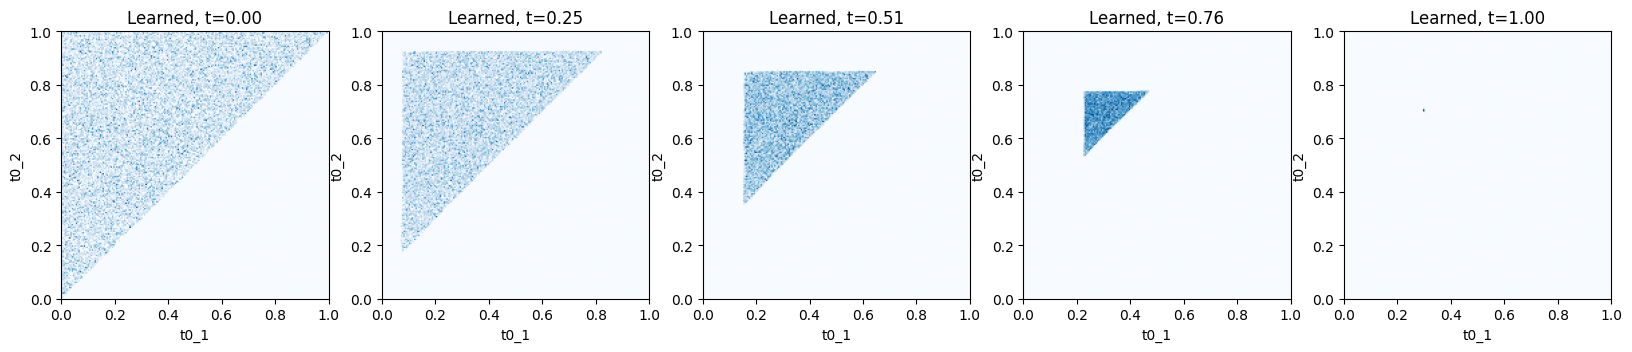

In [9]:
num_samples = 25000  # number of prior samples to transform 
num_marginals = 5   # number of snapshots

# TODO: maybe do this in batches
# use same data point for conditioning all prior samples
simulations = torch.tensor(x_counts, device=device, dtype=torch.float).repeat(num_samples, 1)

# initialize ODE solver
solver = EulerODESolver(vector_field)
nts = 100
ts = torch.linspace(0, 1, nts).to(device)
# ts_2 = torch.linspace(0.90, 1, nts - 100).to(device)
# ts = torch.cat([ts, ts_2])

path = GuidedLinearProbabilityPath(
        p_simple=Prior(),
        p_data=Posterior()
    )

# simulate ODE starting from x0
x0 = path.p_simple.sample(num_samples).to(device)
xts = solver.solve_with_trajectory(x0, ts.view(1, nts, 1).expand(num_samples, nts, 1), y=simulations)

# only save num_marginals snapshots 
record_every_idxs = record_every(nts, nts // (num_marginals - 1))
xts = xts[:, record_every_idxs, :]

# plot snapshots of marginal path
final_snapshot = plot_snapshots(xts, ts, record_every_idxs, num_marginals)

In [10]:
xts = solver.solve_with_trajectory(x0, ts.view(1, nts, 1).expand(num_samples, nts, 1), y=simulations)

100%|██████████| 99/99 [00:04<00:00, 24.41it/s]


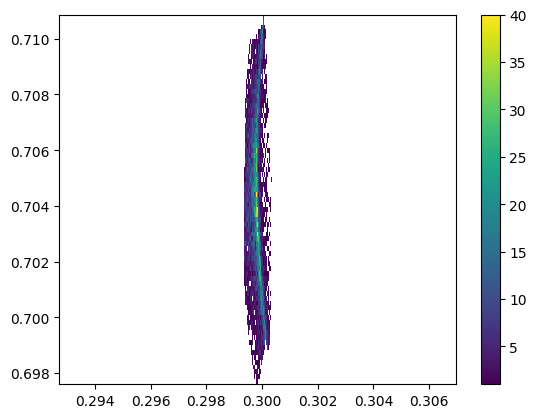

In [10]:
import matplotlib.pyplot as plt
snapshot=xts[:, -1, :]
plt.hist2d(snapshot.cpu()[:,0], snapshot.cpu()[:,1], bins=75, cmin=1)
plt.colorbar()
# plt.xlim(0.75, 0.802)
plt.axis('equal')
plt.show()

In [11]:
nts = 5
ts = torch.linspace(0.97, 1, nts).to(device)
simulations = torch.tensor(x_counts, device=device, dtype=torch.float).repeat(5, 1)
ts = ts.view(-1, 1)
# simulate ODE starting from x0
x0 = path.p_simple.sample(4).to(device)
x0 = torch.cat((x0, torch.tensor([[0.3, 0.7]], device=device)))
print(x0, ts)
# print(vector_field(x0, ts, simulations))
target = torch.tensor([[0.3, 0.7]], device=device).repeat((5, 1))
print(path.conditional_vector_field(x0, target, ts))

differences = (
            vector_field(x0, ts, simulations)
            - path.conditional_vector_field(x0, target, ts)
            ) # shape batch_size, ndim

losses = torch.sum(
    differences ** 2,
    dim = 1 # sum column wise
)
total_loss = torch.sum(losses)

average =  total_loss / 5
print(average)
if torch.isnan(average):
    print("lol")

tensor([[0.2392, 0.7280],
        [0.6825, 0.9119],
        [0.1428, 0.2814],
        [0.5187, 0.6133],
        [0.3000, 0.7000]], device='cuda:0') tensor([[0.9700],
        [0.9775],
        [0.9850],
        [0.9925],
        [1.0000]], device='cuda:0')
tensor([[  2.0261,  -0.9347],
        [-16.9990,  -9.4163],
        [ 10.4786,  27.9090],
        [-29.1607,  11.5667],
        [     nan,      nan]], device='cuda:0')
tensor(nan, device='cuda:0', grad_fn=<DivBackward0>)
lol


In [ ]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(7,7))

# histogram bin range
bins = 100
x_edges = np.linspace(0.2, 0.4, bins + 1)
y_edges = np.linspace(0.6, 0.8, bins + 1)

# initial histogram
xts = xts.cpu()
hist, xedges, yedges, img = ax.hist2d(xts[:, 0, 0], xts[:, 0, 1], bins=[x_edges, y_edges], cmin=1)
# plt.colorbar(img, ax=ax)
# ax.set_title('index = 0')

def update(frame):
    ax.clear()  
    hist, xedges, yedges, img = ax.hist2d(xts[:, frame, 0], xts[:, frame, 1],
                                          bins=100, #[x_edges, y_edges], 
                                          cmin=1)
    ax.set_title(f'timestep = {frame}')
    ax.set_xlim(x_edges[0], x_edges[-1])
    ax.set_ylim(y_edges[0], y_edges[-1])
    ax.plot(true_t0[0], true_t0[1], 'ro', markersize=4)
    
    # plt.colorbar(img, ax=ax)
    return img,

timesteps = np.arange(900, 1000, 2)
ani = animation.FuncAnimation(fig, update, frames=timesteps,
                              interval=200, blit=False)
ani.save('animation.gif')
plt.show()

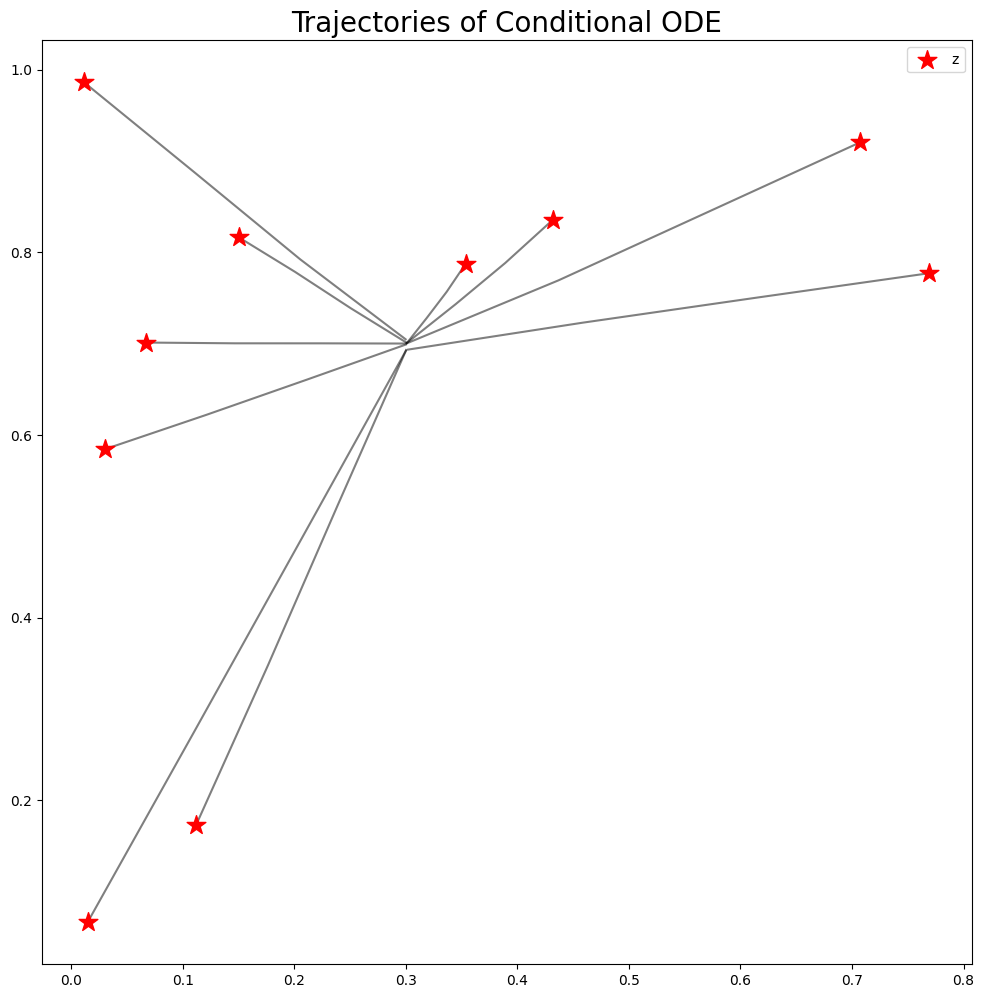

In [130]:
fig, axes = plt.subplots(1,1, figsize=(12, 12))
ax = axes
ax.set_title('trajectories of conditional ODE', fontsize=20)
# ax.scatter(x0[:,0].cpu(), x0[:,1].cpu(), marker='*', color='red', s=200, label='z',zorder=20) # Plot z

x_bounds=(0,1)
y_bounds=(0,1)

# plot N random trajctories
import random
N_traj = 10
traj = [random.choice(range(num_samples)) for i in range(N_traj)]
ax.scatter(x0[traj,0].cpu(), x0[traj,1].cpu(), marker='*', color='red', s=200, label='z',zorder=20) # Plot z

for traj_idx in traj:
    ax.plot(xts[traj_idx,:,0].detach().cpu(), xts[traj_idx,:,1].detach().cpu(), alpha=0.5, color='black')
ax.legend(loc='upper right', markerscale=1)
plt.show()

# corner plot

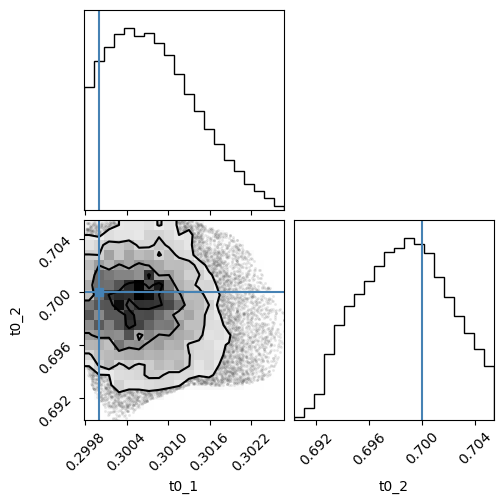

In [124]:
fig = corner(final_snapshot.cpu().numpy(), labels=["t0_1", "t0_2"], truths=np.array(true_t0))#, range=[0.9,0.9])

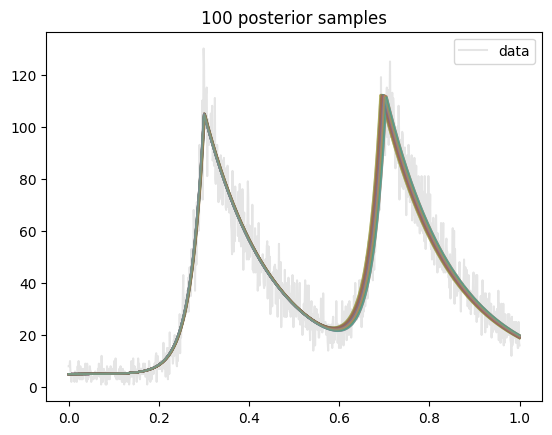

In [125]:
plot_posterior_samples(100, x_counts, final_snapshot.cpu().numpy(), ["t0"], modelparams)

# PP-plot

In [ ]:
# cell for PP-plot